In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_path = "/content/drive/MyDrive/leaves/train"
test_path  = "/content/drive/MyDrive/leaves/test"

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:

DATASET_PATH = "/content/drive/MyDrive/leaves"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [6]:
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
NUM_CLASSES = train_data.num_classes
print("Number of classes:", NUM_CLASSES)
print("Classes:", train_data.class_indices)

Found 4274 images belonging to 12 classes.
Found 110 images belonging to 12 classes.
Number of classes: 12
Classes: {'Alstonia Scholaris': 0, 'Arjun': 1, 'Bael': 2, 'Basil': 3, 'Chinar': 4, 'Gauva': 5, 'Jamun': 6, 'Jatropha': 7, 'Lemon': 8, 'Mango': 9, 'Pomegranate': 10, 'Pongamia Pinnata': 11}


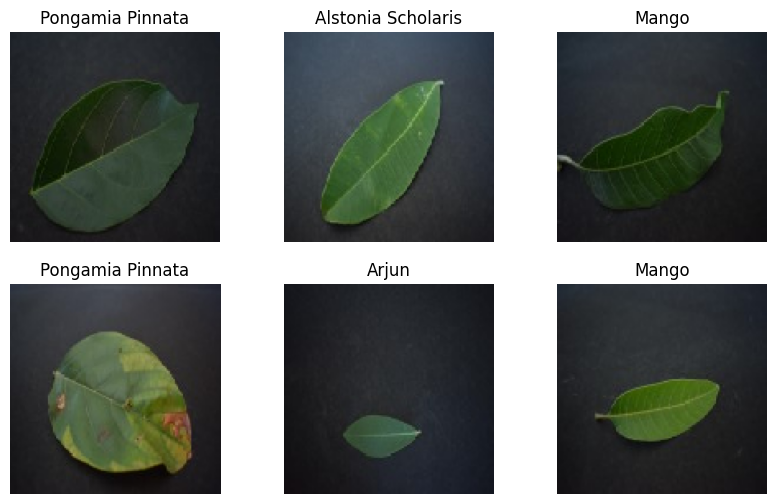

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,868 (28.21 MB)

 Trainable params: 7,393,868 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 1429s 11s/step - accuracy: 0.3444 - loss: 1.9074 - val_accuracy: 0.4364 - val_loss: 1.6085
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 118s 876ms/step - accuracy: 0.5716 - loss: 1.2423 - val_accuracy: 0.6636 - val_loss: 1.1466
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 115s 859ms/step - accuracy: 0.6970 - loss: 0.9068 - val_accuracy: 0.8182 - val_loss: 0.9584
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 114s 850ms/step - accuracy: 0.7506 - loss: 0.7382 - val_accuracy: 0.7727 - val_loss: 0.9983
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 115s 856ms/step - accuracy: 0.7929 - loss: 0.6124 - val_accuracy: 0.8182 - val_loss: 0.8972
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 114s 848ms/step - accuracy: 0.8170 - loss: 0.5259 - val_accuracy: 0.7818 - val_loss: 1.1050
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 113s 845ms/step - accuracy: 0.8409 - loss: 0.4563 - val_accuracy: 0.8273 - val_loss: 1.1332
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 122s 906ms/step - accuracy: 0.8465 - 

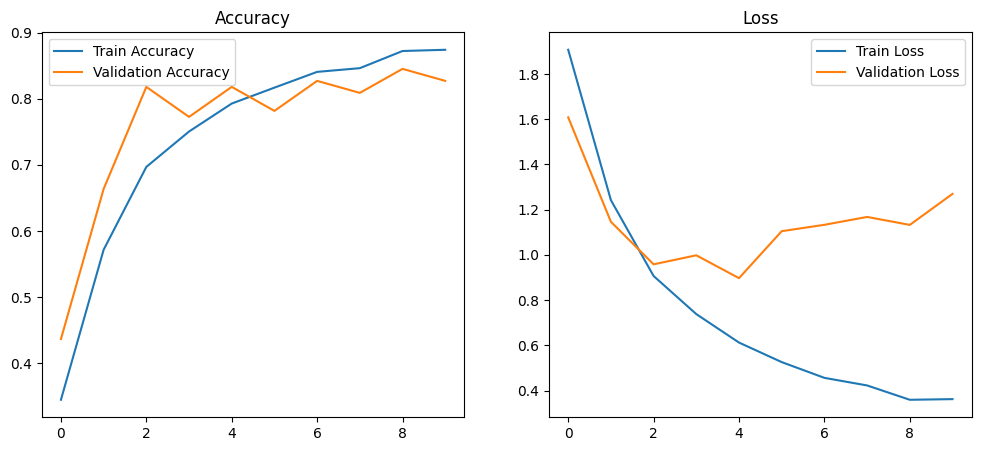

In [10]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [11]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.8273 - loss: 1.2700
Test Accuracy: 0.8272727131843567


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step


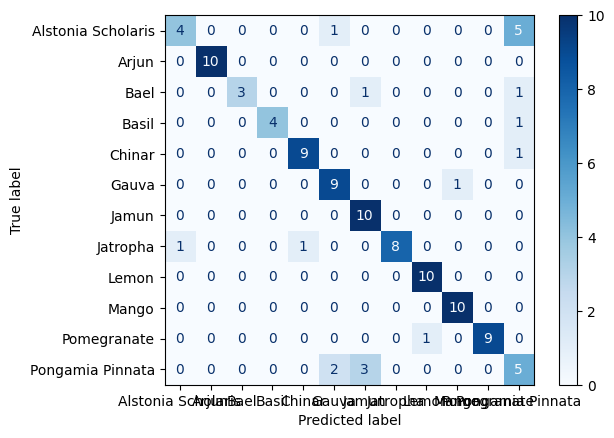

In [12]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [13]:
MODEL_PATH = "/content/drive/MyDrive/leaves/binary_cnn_model.keras"
model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4274 images belonging to 12 classes.
Found 110 images belonging to 12 classes.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_v2 = Sequential()

model_v2.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(64,(3,3),activation='relu'))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Conv2D(128,(3,3),activation='relu'))
model_v2.add(MaxPooling2D(2,2))

model_v2.add(Flatten())

model_v2.add(Dense(256,activation='relu'))
model_v2.add(Dropout(0.5))

model_v2.add(Dense(train_data.num_classes,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
history_v2 = model_v2.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.4621 - loss: 1.5654 - val_accuracy: 0.6727 - val_loss: 1.1786
Epoch 2/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7167 - loss: 0.8575 - val_accuracy: 0.7727 - val_loss: 0.8857
Epoch 3/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8014 - loss: 0.6073 - val_accuracy: 0.8182 - val_loss: 0.8574
Epoch 4/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8627 - loss: 0.4181 - val_accuracy: 0.8000 - val_loss: 0.9488
Epoch 5/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8825 - loss: 0.3566 - val_accuracy: 0.8455 - val_loss: 1.0964
Epoch 6/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9109 - loss: 0.2812 - val_accuracy: 0.8182 - val_loss: 1.2179


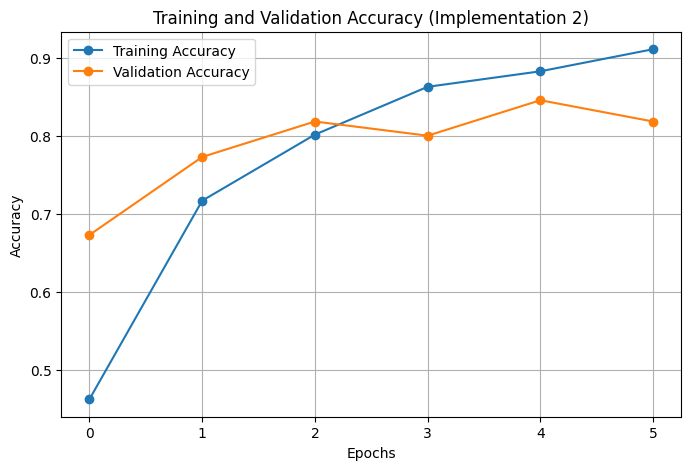

In [20]:
# Plot training & validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy (Implementation 2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

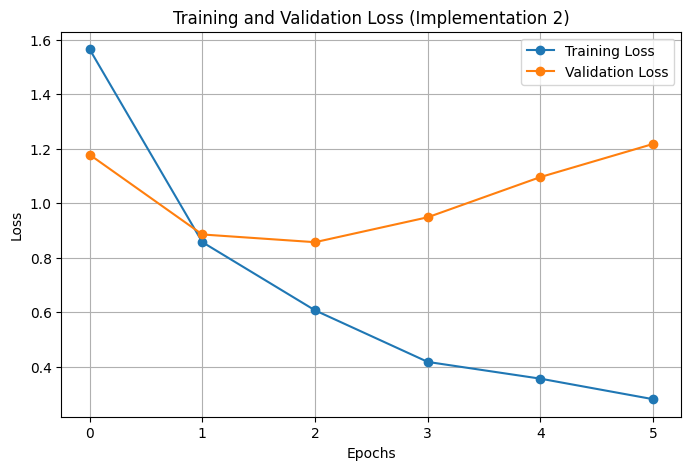

In [21]:
# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history_v2.history['loss'], label='Training Loss', marker='o')
plt.plot(history_v2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss (Implementation 2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step


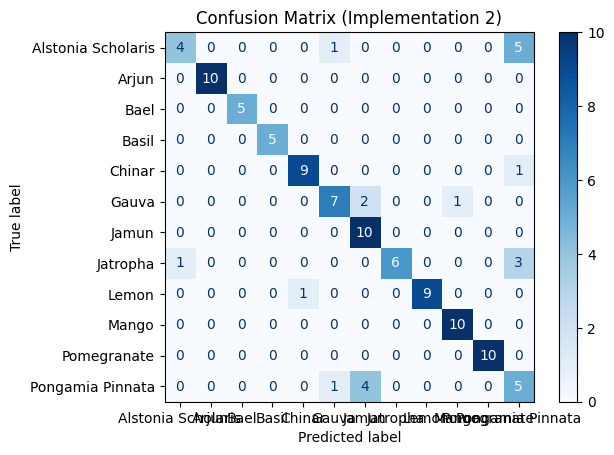

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Reset generator (important)
test_data.reset()

# Get predictions
y_pred = np.argmax(model_v2.predict(test_data), axis=1)
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_data.class_indices.keys())
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Implementation 2)")
plt.show()

In [26]:
model_v2.save("/content/drive/MyDrive/leaves/binary_cnn_model_v2.keras")